In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

In [3]:
mc = pd.read_csv(r"C:\Users\Afdal Hussain\Desktop\Python Projects\Datasets\Mall_Customers.csv")

mc.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
mc.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
mc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
mc.rename(columns={"Annual Income (k$)":"AnnualIncome","Spending Score (1-100)":"SpendingScore"}, inplace=True)

I can see potentially 5 clusters between SpendingScore and AnnualIncome as well as potentially 3 clusters for both Age and AnnualIncome/Spendingscore


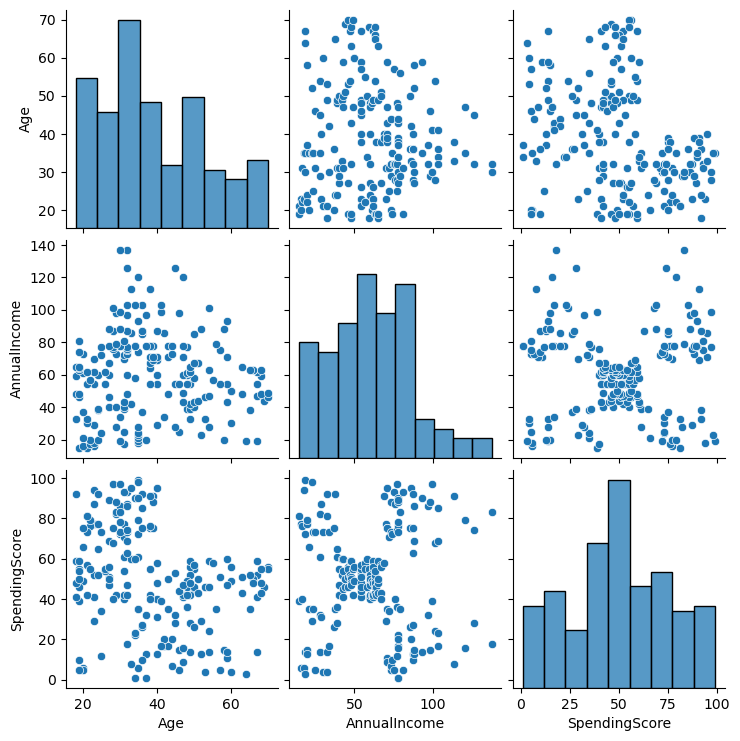

In [10]:
sns.pairplot(mc[["Age", "AnnualIncome", "SpendingScore"]])
print("I can see potentially 5 clusters between SpendingScore and AnnualIncome as well as potentially 3 clusters for both Age and AnnualIncome/Spendingscore")

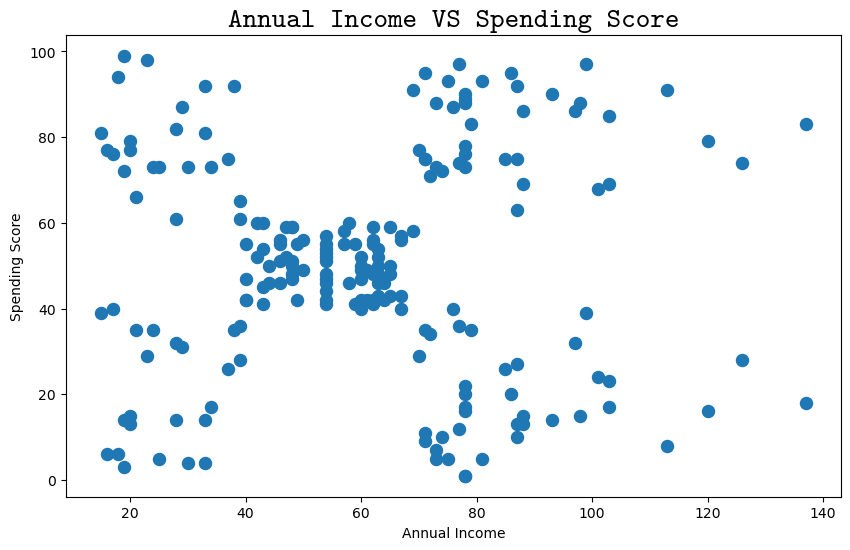

In [18]:
plt.figure(figsize = (10,6))
plt.scatter(mc["AnnualIncome"], mc["SpendingScore"], s = 75)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Annual Income VS Spending Score", fontdict ={"fontname": "cmtt10", "fontsize": 20})
plt.show()

Now I can apply my K Mean algorithm based on the Annual income and Spending score which is demonstrated in the graph above, but first I need to the the elbow method to determine the optimum number of clusters for this group, the idea is to test when adding a new cluster does not add anything meaningful in terms of modelling the data, that point is defined as an elbow point. This method helps to avoid overfitting however, it might not always be very clear or well defined, this method might also not work for all datasets.

In [25]:
x = mc[["AnnualIncome", "SpendingScore"]]
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = "k-means++", max_iter = 300, n_init = 10, random_state = 5)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known

We can ignore the warning this gives us, It's a known issue with scikit-learn's KMeans on Windows when using Intel's MKL math library: MKL and KMeans's internal parallelism can conflict, so sklearn warns you preemptively about a potential memory-leak/performance issue with threading. Im calling KMeans(...) inside a for loop (10 times), so the warning fires 10 times, once per fit.

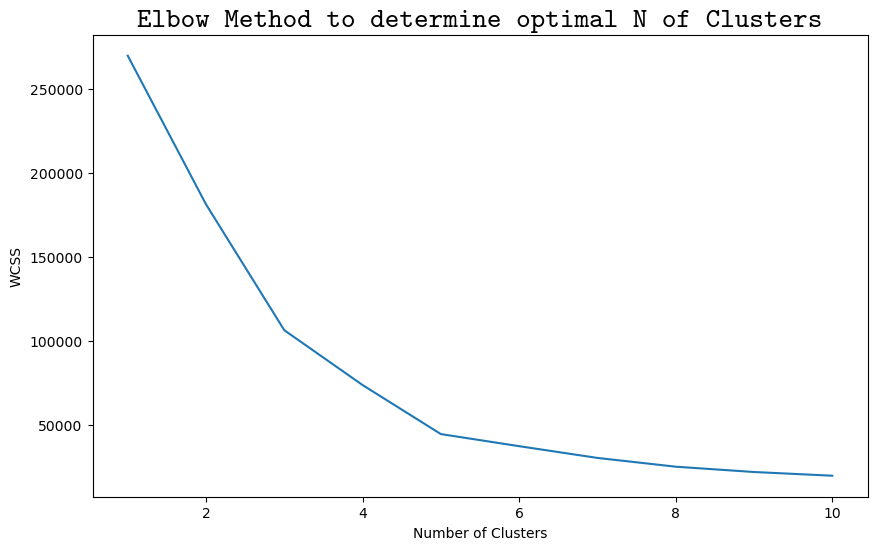

In [26]:
plt.figure(figsize = (10,6))
plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method to determine optimal N of Clusters", fontdict ={"fontname": "cmtt10", "fontsize": 20})
plt.show()


In [27]:
kmeans = KMeans(n_clusters = 5, init = "k-means++", max_iter = 300, n_init = 10, random_state = 5)
y_kmeans = kmeans.fit_predict(x)

C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [28]:
mc["Cluster"] = y_kmeans

In [29]:
mc.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,Cluster
0,1,Male,19,15,39,3
1,2,Male,21,15,81,0
2,3,Female,20,16,6,3
3,4,Female,23,16,77,0
4,5,Female,31,17,40,3


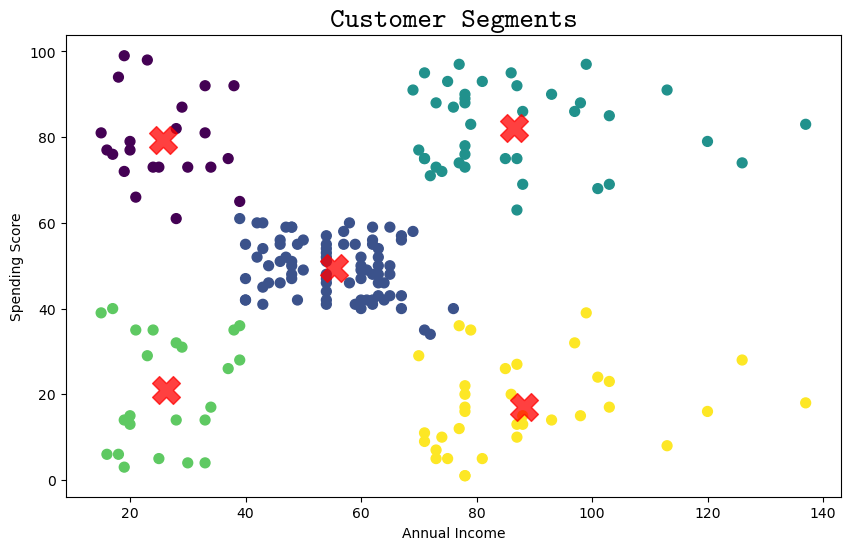

In [34]:
plt.figure(figsize = (10,6))
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c = y_kmeans, s = 50, cmap = "viridis")
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c = "red", s = 400, alpha = .75, marker = "X")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments", fontdict ={"fontname": "cmtt10", "fontsize": 20})
plt.show()

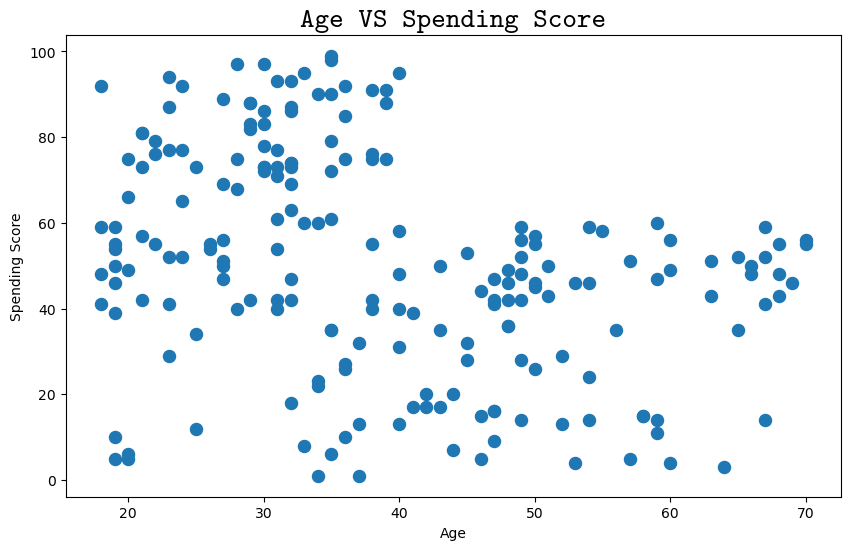

In [35]:
plt.figure(figsize = (10,6))
plt.scatter(mc["Age"], mc["SpendingScore"], s = 75)
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age VS Spending Score", fontdict ={"fontname": "cmtt10", "fontsize": 20})
plt.show()

C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known

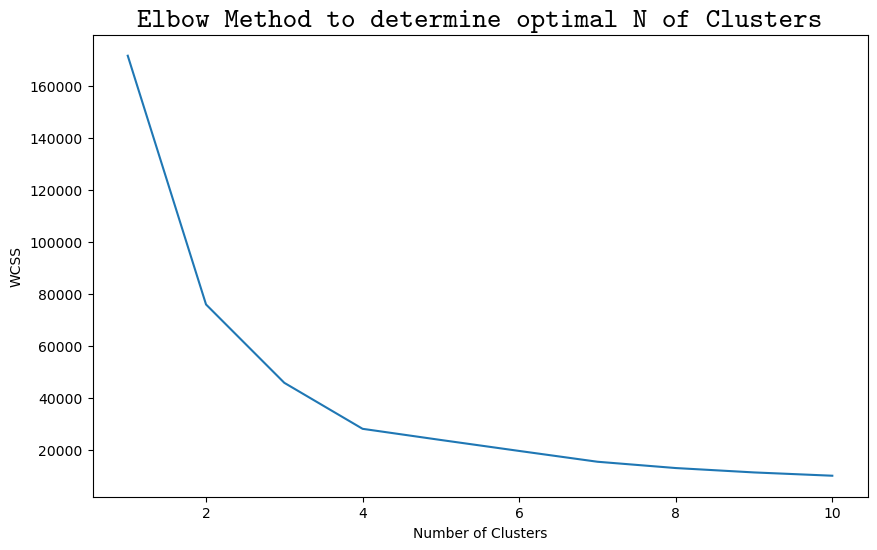

In [36]:
x = mc[["Age", "SpendingScore"]]
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = "k-means++", max_iter = 300, n_init = 10, random_state = 5)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)


plt.figure(figsize = (10,6))
plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method to determine optimal N of Clusters", fontdict ={"fontname": "cmtt10", "fontsize": 20})
plt.show()

In [37]:
kmeans = KMeans(n_clusters = 4, init = "k-means++", max_iter = 300, n_init = 10, random_state = 5)
y_kmeans = kmeans.fit_predict(x)
mc["ClusterAge"] = y_kmeans
mc.head()

C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,AnnualIncome,SpendingScore,Cluster,ClusterAge
0,1,Male,19,15,39,3,0
1,2,Male,21,15,81,0,1
2,3,Female,20,16,6,3,3
3,4,Female,23,16,77,0,1
4,5,Female,31,17,40,3,0


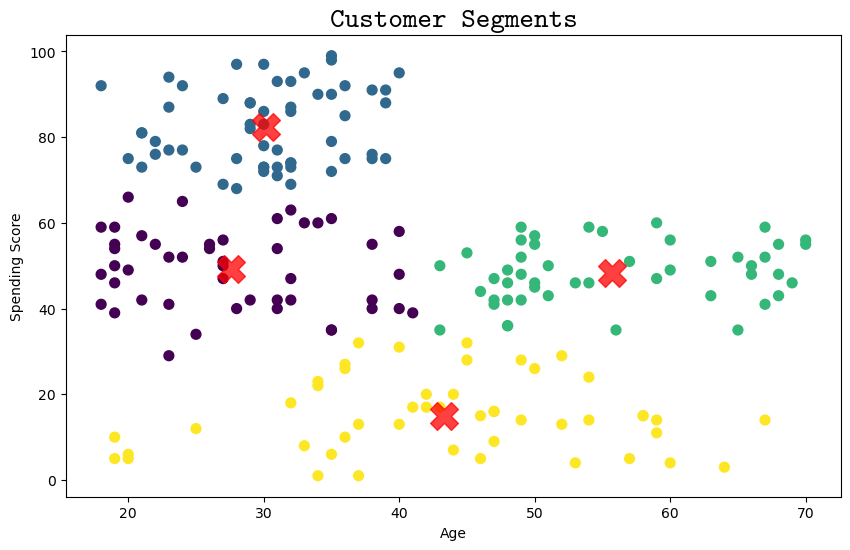

In [38]:
plt.figure(figsize = (10,6))
plt.scatter(x.iloc[:, 0], x.iloc[:, 1], c = y_kmeans, s = 50, cmap = "viridis")
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c = "red", s = 400, alpha = .75, marker = "X")
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Customer Segments", fontdict ={"fontname": "cmtt10", "fontsize": 20})
plt.show()

C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known

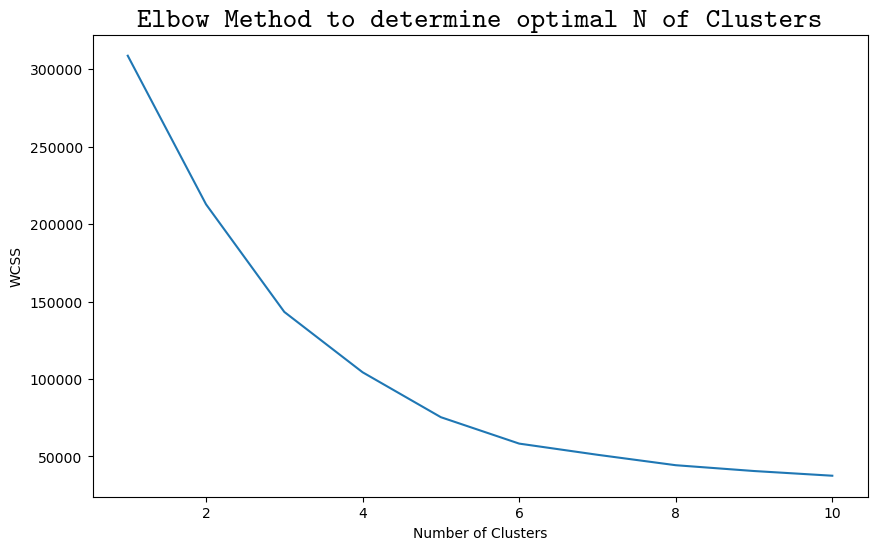

In [39]:
x1 = mc[["Age", "AnnualIncome", "SpendingScore"]]
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters = i, init = "k-means++", max_iter = 300, n_init = 10, random_state = 5)
    kmeans.fit(x1)
    wcss.append(kmeans.inertia_)

plt.figure(figsize = (10,6))
plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method to determine optimal N of Clusters", fontdict ={"fontname": "cmtt10", "fontsize": 20})
plt.show()

In [40]:
kmeans = KMeans(n_clusters = 6, init = "k-means++", max_iter = 300, n_init = 10, random_state = 5)
y_kmeans = kmeans.fit_predict(x1)
mc["ClusterAgeIncomeSpend"] = y_kmeans
mc.head()

C:\Users\Afdal Hussain\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,AnnualIncome,SpendingScore,Cluster,ClusterAge,ClusterAgeIncomeSpend
0,1,Male,19,15,39,3,0,4
1,2,Male,21,15,81,0,1,5
2,3,Female,20,16,6,3,3,4
3,4,Female,23,16,77,0,1,5
4,5,Female,31,17,40,3,0,4


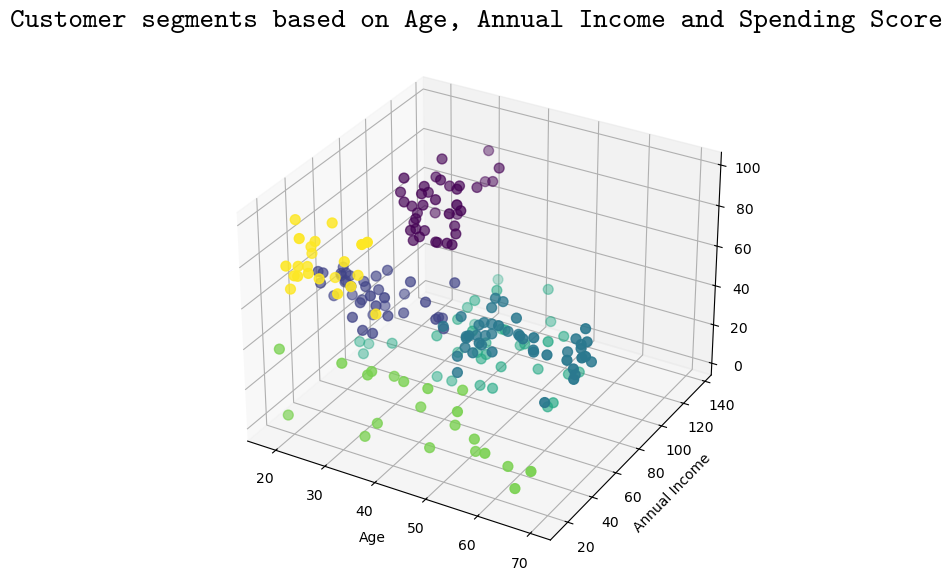

In [42]:
fig = plt.figure(figsize = (10,7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(mc["Age"], mc["AnnualIncome"], mc["SpendingScore"], c = mc["ClusterAgeIncomeSpend"], s = 50, cmap = "viridis")
ax.set_xlabel("Age")
ax.set_ylabel("Annual Income")
plt.title("Customer segments based on Age, Annual Income and Spending Score", fontdict ={"fontname": "cmtt10", "fontsize": 20})
plt.show()